# Worst-of Call Option | NVDA x AVGO 

### Bebiakina Anastasiia

## 1. Instrument Choice

### Macroeconomic Context

- High Interest rates: 6‑month US Treasury yields are around 3.5-4.5%, which puts pressure on the high‑growth tech companies. 
- Inflation in developed economies remains significant.  
- AI infrastructure spending continues to be dominant. Hyperscalers (Microsoft, Google, Meta, Amazon) have committed >200 bn dollars in capex for 2025‑2026, increasing demand for AI technologies.  
- Geopolitical risks: US‑China export controls and TSMC’s concentration risk (most advanced chips made in Taiwan) create supply chain uncertainty.  

Despite the drawbacks, the long‑term AI trend continues.

### Stock Selection: NVIDIA (NVDA) and Broadcom (AVGO)

| Company | Role | Products / Clients | Financial Analysis | Risks |
|---------|------|------------------------|----------------------|-------|
| **NVIDIA** | Dominant AI training/inference GPUs | H100, B200 (Blackwell); hyperscalers, enterprises | Revenue grew about 7x in two years; P/E 30‑40, PEG 0.2 (very high expected earnings growth) | High valuation, customer concentration, ASIC competition (AMD, custom chips) |
| **Broadcom** | Diversified semiconductor + software (VMware) | Custom AI ASICs (XPUs) for Google, Meta, Apple; networking, storage | P/E 60, PEG 0.76; stable free cash flow, software recurring revenue | Cyclical semiconductor demand, integration risks (VMware), smartphone dependence |

Both companies are **highly correlated** (historical $\rho \approx 0.68$) because they share the same macro driver – AI capex. Their volatilities differ: NVDA is the higher‑beta (higher‑growth underlying) while AVGO offers a more defensive profile.

### Why a Worst‑of Call option?

A **Worst‑of Call** pays based on the worse‑performing of the two underlyings (stocks).

**Benefits of this type of an option:**:

- Bullish on both stocks: we believe neither will significantly underperform over 6 months.  
- The worst‑of call is substantially cheaper than a vanilla call on either stock.  
- Correlation exposure is Long. When correlation rises, both stocks move together, lifting the worst performer $\to$ option value increases.  
- Premium saving (lower price than a vanilla instrument) is the compensation the seller receives for bearing correlation risk.

**Key risks include:**  
- If one stock falls dramatically, the entire option becomes worthless.  
- If correlation drops (for instance, due to sector rotation), the option loses value even if both stocks are individually up.

### Relevance

The AI industry is and heavily influenced by macro factors (interest rates, trade policies, technological breakthroughs). Current dynamics (AI‑driven capex) make NVDA and AVGO good underlying stocks for a multi‑asset exotic option.  

In [35]:
# find spot prices & standard deviation and correlation parameters using real data (yahooFinance)

import yfinance as yf
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

tickers = ['NVDA', 'AVGO']
period = '1y' # 1 year of daily data
annualization_factor = 252  # trading days per year

# download data
data = yf.download(tickers, period=period)['Close']
data = data.dropna()

# spot prices
nvda_spot = data['NVDA'].iloc[-1]
avgo_spot = data['AVGO'].iloc[-1]

print("Current market spot:")
print(f"  NVDA: {nvda_spot:.4f}")
print(f"  AVGO: {avgo_spot:.4f}\n")

# daily returns
log_returns = np.log(data / data.shift(1)).dropna()

# calculate volatilities
daily_vols = log_returns.std()
annual_vols = daily_vols * np.sqrt(annualization_factor)

print("Historical volatility (1 year)")
for ticker in tickers:
    print(f"  {ticker}: {annual_vols[ticker]:.2%}")

# correlation matrix
corr_matrix = log_returns.corr()
correlation = corr_matrix.iloc[0, 1]

print(f"\nCorrelation (1 year): {correlation:.4f}")

[*********************100%***********************]  2 of 2 completed

Current market spot:
  NVDA: 176.6150
  AVGO: 311.5400

Historical volatility (1 year)
  NVDA: 39.28%
  AVGO: 45.91%

Correlation (1 year): 0.6787


### Remaining parameters 
 
$r$: 4.3%  
$T$: 0.5y (6m)   
$K$: 1.0 (ATM, % of initial)  

The payoff is **normalized**: spot prices are divided by their initial values, so both start at 1.0.   
Strike $K = 1.0$ is at-the-money.  
The option pays 1 USD per unit notional per 1% outperformance of the worst performer.

*Risk-free rate ($r$) source: https://ycharts.com/indicators/10_year_treasury_rate  
Given relatively low short-term variability of Treasury yields, we assume constant risk-free rate*

## 2. Payoff Structure

### Worst-of Call payoff
$$\text{Payoff} = \max\left(0,\ \min\left(\frac{S_1(T)}{S_1(0)},\ \frac{S_2(T)}{S_2(0)}\right) - K\right)$$

The option pays off only if both stocks are above their initial levels at maturity. Specifically, it pays the return of the **worse** performer. If either stock drops significantly, the option becomes worthless.

**This is cheaper than a vanilla call.**  
A vanilla call on stock $i$ pays $max(0, \frac{S_i(T)}{S_i(0)} - K)$. The worst-of call adds an additional condition: even if one stock increases significantly, we only receive the upside of the worst stock (the other one). This reduced expected payoff results in a lower premium.

### Monte Carlo 
Under risk-neutral measure, each stock follows GBM:
$$dS_i = r\, S_i\, dt + \sigma_i\, S_i\, dW_i$$
$$S_i(T) = S_i(0)\exp\left(\left(r - \frac{\sigma_i^2}{2}\right)T + \sigma_i\sqrt{T}\, Z_i\right)$$

where $Z_1, Z_2$ are correlated standard normals with correlation $\rho$. We generate them via **Cholesky decomposition**:

$$\begin{pmatrix} Z_1 \\ Z_2 \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ \rho & \sqrt{1-\rho^2} \end{pmatrix} \begin{pmatrix} W_1 \\ W_2 \end{pmatrix}$$

where $W_1, W_2 \sim N(0,1)$ i.i.d.

## 3. Pricing

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm

seed = np.random.seed(67)

In [36]:
# given market parameters 

S1_0  = nvda_spot
S2_0  = avgo_spot
sigma1 = annual_vols['NVDA']    # NVDA annualized vol
sigma2 = annual_vols['AVGO']    # AVGO annualized vol
rho    = correlation
r      = 0.043   # risk-free rate
T      = 0.5     # 6-month maturity
K      = 1.0     # ATM strike
N      = 500_000 # number of Monte Carlo paths

In [51]:
# generate N correlated GBM stock values using Cholesky decomposition

def generate_correlated_paths(N, rho, sigma1, sigma2, r, T):
    
    # independent standard normals
    W1 = np.random.standard_normal(N)
    W2 = np.random.standard_normal(N)
    
    # Cholesky: Z1 = W1, Z2 = rho * W1 + sqrt(1 - rho^2) * W2
    Z1 = W1
    Z2 = rho * W1 + np.sqrt(1 - rho**2) * W2
    
    # GBM values (we don't forget to normalize!)
    R1 = np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * Z1)
    R2 = np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * Z2)
    
    return R1, R2

# price the option

def price_worst_of_call(N, rho, sigma1, sigma2, r, T, K, S1_0=1.0, S2_0=1.0):

    R1, R2 = generate_correlated_paths(N, rho, sigma1, sigma2, r, T)
    
    # payoff is calculated as: max(0, min(R1, R2) - K)
    payoffs = np.maximum(0, np.minimum(R1, R2) - K)
    
    # present value (discounting)
    discount = np.exp(-r * T)
    price = discount * np.mean(payoffs)
    se = discount * np.std(payoffs) / np.sqrt(N)
    
    return price, se


# calculate base price
price, se = price_worst_of_call(N, rho, sigma1, sigma2, r, T, K)
print(f"Price: {price:.6f}  (% of initial spot)")
print(f"Standard Error: {se:.6f}")
print(f"95% CI: [{price - 1.96*se:.6f}, {price + 1.96*se:.6f}]")


Price: 0.073097  (% of initial spot)
Standard Error: 0.000216
95% CI: [0.072674, 0.073521]


In [52]:
# compare to individual vanilla calls 

# price of a vanilla option using Black-Scholes
def vanilla_call(S0, K, r, T, sigma):

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

# normalized -> S0 = 1

vanilla1 = vanilla_call(1.0, K, r, T, sigma1)
vanilla2 = vanilla_call(1.0, K, r, T, sigma2)

print("Price comparison:")
print(f"  NVDA vanilla call:   {vanilla1:.4f}  ({vanilla1:.2%})")
print(f"  AVGO vanilla call:   {vanilla2:.4f}  ({vanilla2:.2%})")
print(f"  Worst-of call:       {price:.4f}  ({price:.2%})")

Price comparison:
  NVDA vanilla call:   0.1202  (12.02%)
  AVGO vanilla call:   0.1385  (13.85%)
  Worst-of call:       0.0731  (7.31%)


## 4. Greeks 

Greeks are computed using **finite differences** methodology.

The finite differences approximates derivatives using price differences.

Formulae for delta, gamma and vega:

**For Delta (first derivative):**

$$
\Delta_i \approx \frac{P(S_0^{(i)} + \epsilon) - P(S_0^{(i)} - \epsilon)}{2\epsilon}
$$

**For Gamma (second derivative):**

$$
\Gamma_i \approx \frac{P(S_0^{(i)} + \epsilon) - 2P(S_0^{(i)}) + P(S_0^{(i)} - \epsilon)}{\epsilon^2}
$$

**For Vega:**

$$
\nu_i \approx \frac{P(\sigma_i + \epsilon) - P(\sigma_i - \epsilon)}{2\epsilon}
$$


- $P$ = price of the option
- $\epsilon$ = bump size

In [53]:
# flexible pricing function implements bumping spots 

def price_woc(rho=rho, sigma1=sigma1, sigma2=sigma2, spot1_mult=1.0, spot2_mult=1.0, 
              r=r, T=T, K=K, N=N, seed=67):

    np.random.seed(seed)
    W1 = np.random.standard_normal(N)
    W2 = np.random.standard_normal(N)
    Z1 = W1
    Z2 = rho * W1 + np.sqrt(1 - rho**2) * W2
    
    # spot multiplier shifts the initial spot: S_new(T)/S0 = spot_mult * R(T)
    R1 = spot1_mult * np.exp((r - 0.5 * sigma1**2) * T + sigma1 * np.sqrt(T) * Z1)
    R2 = spot2_mult * np.exp((r - 0.5 * sigma2**2) * T + sigma2 * np.sqrt(T) * Z2)
    
    payoffs = np.maximum(0, np.minimum(R1, R2) - K)
    return np.exp(-r * T) * np.mean(payoffs) # discounting


bump = 0.01  # 1% bump 

V0 = price_woc()

# delta 
V_S1_up = price_woc(spot1_mult=1 + bump)
V_S1_down = price_woc(spot1_mult=1 - bump)
V_S2_up = price_woc(spot2_mult=1 + bump)
V_S2_down = price_woc(spot2_mult=1 - bump)

delta1 = (V_S1_up - V_S1_down) / (2 * bump)
delta2 = (V_S2_up - V_S2_down) / (2 * bump)

# gamma 
gamma1 = (V_S1_up - 2 * V0 + V_S1_down) / bump**2
gamma2 = (V_S2_up - 2 * V0 + V_S2_down) / bump**2

# vega
V_v1_up = price_woc(sigma1=sigma1 + bump)
V_v1_down = price_woc(sigma1=sigma1 - bump)
V_v2_up = price_woc(sigma2=sigma2 + bump)
V_v2_down = price_woc(sigma2=sigma2 - bump)

vega1 = (V_v1_up - V_v1_down) / (2 * bump)
vega2 = (V_v2_up - V_v2_down) / (2 * bump)

# cross-Gamma 
V_up_up = price_woc(spot1_mult=1+bump, spot2_mult=1+bump)
V_up_down = price_woc(spot1_mult=1+bump, spot2_mult=1-bump)
V_down_up = price_woc(spot1_mult=1-bump, spot2_mult=1+bump)
V_dn_dn = price_woc(spot1_mult=1-bump, spot2_mult=1-bump)

cross_gamma = (V_up_up - V_up_down - V_down_up + V_dn_dn) / (4 * bump**2)

# correlation sensitivity 
V_rho_up   = price_woc(rho=rho + bump)
V_rho_down = price_woc(rho=rho - bump)

corr_sens = (V_rho_up - V_rho_down) / (2 * bump)

print(f"Base price:           {V0:.6f}\n")
print(f"Delta (NVDA):         {delta1:.4f}")
print(f"Delta (AVGO):         {delta2:.4f}")
print(f"Gamma (NVDA):         {gamma1:.4f}")
print(f"Gamma (AVGO):         {gamma2:.4f}")
print(f"Vega (NVDA, per 1%):  {vega1/100:.6f}")
print(f"Vega (AVGO, per 1%):  {vega2/100:.6f}")
print(f"Cross-Gamma:          {cross_gamma:.4f}")
print(f"Corr. sensitivity:    {corr_sens:.6f}  (per 1% change)")

Base price:           0.072520

Delta (NVDA):         0.2278
Delta (AVGO):         0.1752
Gamma (NVDA):         -0.2801
Gamma (AVGO):         -0.3301
Vega (NVDA, per 1%):  0.000918
Vega (AVGO, per 1%):  0.000484
Cross-Gamma:          0.9270
Corr. sensitivity:    0.083962  (per 1% change)


### Graphical Greeks

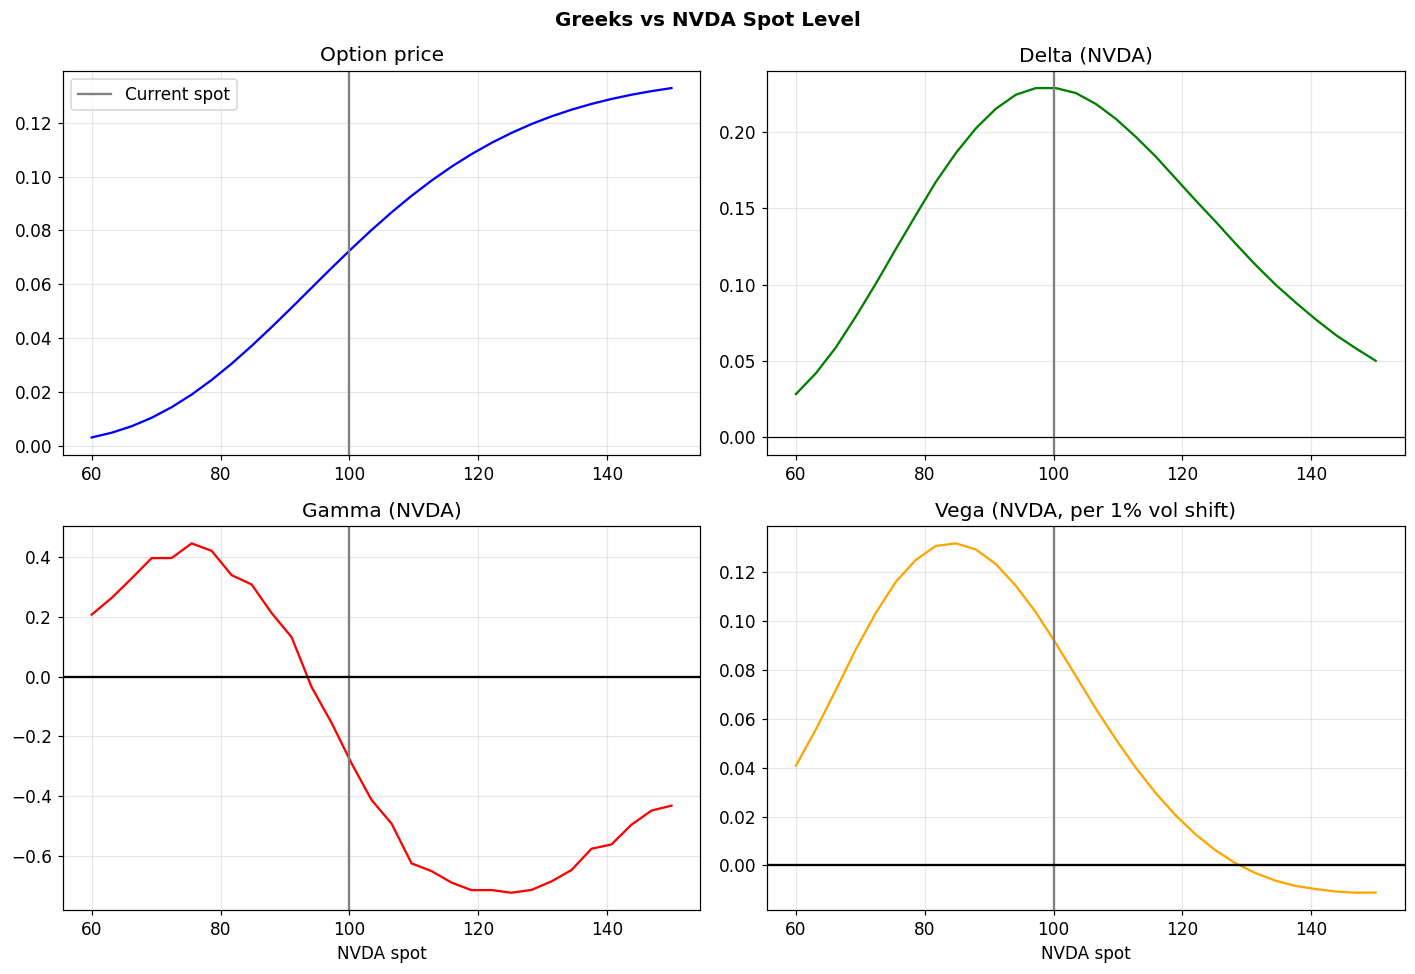

In [55]:
# compute Greeks across a range of spot multipliers for S1 (NVDA)
# hold S2 at its initial level

spot_range = np.linspace(0.60, 1.50, 30)   # S1 ranges from 60% to 150% of initial
N_greek = 200_000 

prices_grid = []
deltas1_grid = []
gammas1_grid = []
vegas1_grid  = []

for s in spot_range:
    v0  = price_woc(spot1_mult=s, N=N_greek)
    vup = price_woc(spot1_mult=s*(1+bump), N=N_greek)
    vdn = price_woc(spot1_mult=s*(1-bump), N=N_greek)
    vuv = price_woc(spot1_mult=s, sigma1=sigma1+bump, N=N_greek)
    vdv = price_woc(spot1_mult=s, sigma1=sigma1-bump, N=N_greek)
    
    prices_grid.append(v0)
    deltas1_grid.append((vup - vdn) / (2 * bump))
    gammas1_grid.append((vup - 2*v0 + vdn) / bump**2)
    vegas1_grid.append( (vuv - vdv) / (2 * bump) )

spot_pct = spot_range * 100  # x-axis as % of initial

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Greeks vs NVDA Spot Level", fontsize=13, fontweight='bold')

# Price
axes[0,0].plot(spot_pct, prices_grid, color='blue')
axes[0,0].axvline(100, color='gray', label='Current spot')
axes[0,0].set_title('Option price')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Delta
axes[0,1].plot(spot_pct, deltas1_grid, color='green')
axes[0,1].axvline(100, color='gray')
axes[0,1].axhline(0, color='black')
axes[0,1].set_title('Delta (NVDA)')
axes[0,1].grid(True, alpha=0.3)

# Gamma
axes[1,0].plot(spot_pct, gammas1_grid, color='red')
axes[1,0].axvline(100, color='gray')
axes[1,0].axhline(0, color='black')
axes[1,0].set_title('Gamma (NVDA)')
axes[1,0].set_xlabel('NVDA spot')
axes[1,0].grid(True, alpha=0.3)

# Vega
axes[1,1].plot(spot_pct, vegas1_grid, color='orange')
axes[1,1].axvline(100, color='gray')
axes[1,1].axhline(0, color='black')
axes[1,1].set_title('Vega (NVDA)')
axes[1,1].set_xlabel('NVDA spot')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

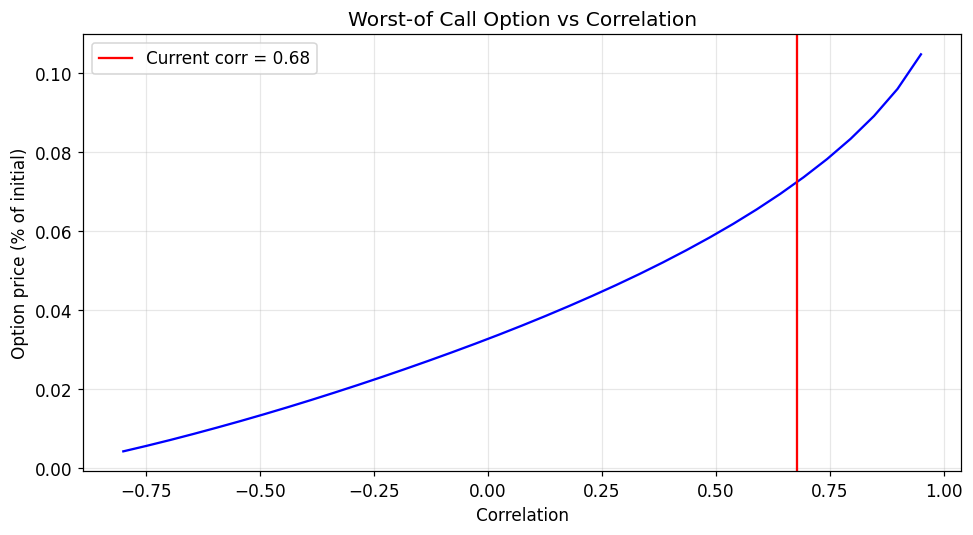

The positive slope confirms that Worst-of Call is LONG correlation.


In [46]:
# correlation sensitivity diagram

rho_range = np.linspace(-0.80, 0.95, 35)
prices_vs_rho = [price_woc(rho=r_, N=200_000) for r_ in rho_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rho_range, prices_vs_rho, color='blue')
ax.axvline(rho, color='red', label=f'Current corr = 0.68')
ax.set_xlabel('Correlation')
ax.set_ylabel('Option price (% of initial)')
ax.set_title('Worst-of Call Option vs Correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The positive slope confirms that Worst-of Call is LONG correlation.")

### Greek commentary

#### Delta 
- **NVDA delta (0.2278) > AVGO delta (0.1752)**   
The current spot prices are not equal in relative terms (NVDA at 176.6, AVGO at 311.5). When normalised to initial values (both start at 1.0), the option is ATM. However, the higher spot of AVGO means a 1% move in AVGO represents a larger absolute dollar change. Because NVDA’s relative price is lower, the same percentage move has a smaller absolute impact, but the resulting analysis shows a higher probability that NVDA ends as the worst because of its lower spot. Moreover, with negative gamma, the delta is already decreasing.

#### Gamma 
- **Both gammas are negative** (worst‑of options).  
As either stock rises significantly above the other, the option’s payoff becomes limited by the lower one. Further increases in the already‑higher stock do not help. So, delta decreases as the stock increases, producing negative gamma.  

#### Vega 
- **Vega is positive for both**, but NVDA’s vega (0.000918) is almost twice AVGO’s (0.000484).  
This reflects that increasing NVDA’s volatility raises the probability that AVGO ends as the better performer. The effect is smaller for AVGO because it is already the higher‑vol name.

#### Cross‑gamma
- **Strongly positive (0.927)**  
When both stocks rise together, the option gains more than the sum of individual delta effects. This convexity arises because a joint changes lifts the minimum of the two returns faster than linearly.

#### Correlation sensitivity 
- **Positive (0.084 per 1% increase in ρ)**  
Confirms the worst‑of call is **long correlation**. The two stocks move together, reducing the gap between them and benefiting the worst performer.


## 5. Risk management 

#### 1. Negative convexity (Gamma)
Both gammas are negative, meaning delta **decreases** as the underlying rises. This is not surprising for worst‑of options: once one stock shifts ahead, further gains (upward shifts) add little value.  
**Hedging:** delta must be rebalanced frequently (daily). 

#### 2. Correlation risk
The option is **long correlation**. If the actual correlation between NVDA and AVGO drops below the modelled 0.68 the option loses value even if both stocks are individually up.  
**Hedging:** sell basket call, buy single‑stock calls to offset correlation exposure.

#### 3. Worst‑of drag
If either stock performs badly, the payoff is capped by the underperformer. A strong increase in the other stock provides no benefit.  
**Mitigation:** choose underlyings with similar risk profiles and high historical correlation (incorporated already).

#### 4. Volatility risk
Vega is positive but modest. A 1 percentage point increase in NVDA vol adds 1.27% to option price; for AVGO, 0.67%. However, volatility spikes often coincide with price drops, partially offsetting gains.  
**Hedging:** use ATM straddles or variance swaps on each underlying.

#### 5. Model risk
We assumed constant volatility and correlation (GBM). In reality, volatilities are stochastic and often negatively correlated with returns. Jumps are not captured.  
**Mitigation:** stress‑test with higher vol scenarios and lower correlation; or incorporate more difficult structure (I'm not smart enough yet).

#### 6. Liquidity & counterparty risk
Worst‑of calls are OTC instruments with wide bid‑offer spreads, so early termination might be difficult.  
**Mitigation:** ensure sufficient documentation with a strong counterparty.

### Conclusion:

The worst‑of call offers cheap leveraged upside when both stocks move together, but its negative gamma and long correlation require active risk management and a bullish view on both correlation and joint performance.